# 18 — Aggregate GA Counterfactual Analysis — Helpdesk

Runs GA counterfactual search (notebook 17) on many prefixes, then aggregates results
to understand **model-level** patterns:

1. **Prediction transitions** — Which prediction flips occur most easily?
2. **Feature importance** — Which features are changed most often in successful CFs?
3. **Positional sensitivity** — Do early or late events matter more?
4. **Minimal changes** — How many changes are needed to flip a prediction?

In [1]:
import sys
import os
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
import torch

# --- Load dataset + prediction model ---
data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
full_dataset = torch.load(data_path, weights_only=False)
dataset = full_dataset

sample = dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Dataset: {len(dataset)} sequences, {n_cat} cat, {n_num} num, seq_len={seq_len}')

from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

model_path = _current / 'src' / 'notebooks' / 'training_variational_dropout' / 'Helpdesk' / 'Helpdesk_full_grad_norm_new_4layer.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(model_path), dropout=0.0)
model.eval()
print(f'Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters')

# --- TensorDecoder + activity vocabulary ---
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(full_dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Dataset: 6077 sequences, 12 cat, 4 num, seq_len=18
Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('VariantIndex', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123

In [3]:
# Load pre-mined constraints
import pickle

constraints_pkl_path = _current / 'encoded_data' / 'helpdesk_constraints.pkl'
with open(constraints_pkl_path, 'rb') as f:
    constraints_data = pickle.load(f)

all_constraints = constraints_data['all']
print(f'Constraints: {len(all_constraints)} (from {constraints_pkl_path.name})')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


Constraints: 23 (from helpdesk_constraints.pkl)


In [4]:
from src.interpretability.perturbation_methods import (
    GACounterfactual, GACounterfactualConfig, create_ga_counterfactual_for_model,
)

MUTABLE_CAT_INDICES = [0, 1, 2]
CASE_LEVEL_CAT_INDICES = [2]

config = GACounterfactualConfig(
    population_size=200,
    n_generations=50,
    crossover_rate=0.8,
    mutation_rate=0.3,
    tournament_size=5,
    elite_size=5,
    mutable_cat_indices=MUTABLE_CAT_INDICES,
    case_level_cat_indices=CASE_LEVEL_CAT_INDICES,
    w_validity=5.0,
    w_proximity=1.0,
    w_sparsity=1.0,
    w_plausibility=1.0,
    w_conformance=2.0,
    top_k=5,
    diversity_threshold=0.3,
    activity_feature=ACTIVITY_FEATURE,
    verbose=False,  # suppress per-generation output for batch mode
)

ga = create_ga_counterfactual_for_model(
    model=model,
    dataset=dataset,
    activity_names=activity_names,
    config=config,
    constraints=all_constraints,
    cat_feature_names=decoder.cat_features,
)
print(f'GA Counterfactual ready')

GA Counterfactual ready


## Prefix Sampling

Sample unique cases and generate prefixes at varying lengths (2 .. trace_len-1)
to cover early, mid, and late positions.

In [5]:
import numpy as np
import pandas as pd
import time

# === Configuration ===
N_PREFIXES = 100          # total number of prefixes to explain
MAX_CASES_TO_SCAN = 2000  # how far into the dataset to scan for unique cases

# --- Collect unique cases ---
cases = []
seen_cases = set()
for i in range(min(MAX_CASES_TO_SCAN, len(dataset))):
    cat_t, num_t, case_id = dataset[i]
    if case_id in seen_cases:
        continue
    seen_cases.add(case_id)
    act = cat_t[0]
    trace_len = int((act != 0).sum().item())
    if trace_len < 3:  # need at least length 3 for prefix_len in [2, trace_len-1]
        continue
    cases.append({'dataset_idx': i, 'case_id': case_id, 'trace_len': trace_len})

print(f'Found {len(cases)} unique cases with trace_len >= 3')

# --- Generate (case, prefix_len) pairs ---
prefix_pool = []
for case in cases:
    tl = case['trace_len']
    for plen in range(2, tl):  # prefix lengths 2 .. trace_len-1
        prefix_pool.append({
            'dataset_idx': case['dataset_idx'],
            'case_id': case['case_id'],
            'trace_len': tl,
            'prefix_len': plen,
        })

print(f'Total prefix pool: {len(prefix_pool)} (case x prefix_len combinations)')

# --- Sample N_PREFIXES from the pool ---
rng = np.random.default_rng(42)
if len(prefix_pool) <= N_PREFIXES:
    selected_prefixes = prefix_pool
else:
    indices = rng.choice(len(prefix_pool), size=N_PREFIXES, replace=False)
    selected_prefixes = [prefix_pool[i] for i in sorted(indices)]

print(f'Selected {len(selected_prefixes)} prefixes for analysis')

# Show prefix length distribution
plen_counts = pd.Series([p['prefix_len'] for p in selected_prefixes]).value_counts().sort_index()
print(f'\nPrefix length distribution:\n{plen_counts.to_string()}')

Found 301 unique cases with trace_len >= 3
Total prefix pool: 903 (case x prefix_len combinations)
Selected 100 prefixes for analysis

Prefix length distribution:
2    33
3    34
4    33


## Batch GA Loop

Run `ga.explain()` on each selected prefix and collect all `GACounterfactualExplanation` objects.

In [6]:
from src.interpretability.perturbation_methods import GACounterfactualExplanation

results = []  # List[Tuple[dict, GACounterfactualExplanation]]
t0 = time.time()

for i, prefix_info in enumerate(selected_prefixes):
    idx = prefix_info['dataset_idx']
    plen = prefix_info['prefix_len']
    trace_len = prefix_info['trace_len']

    cat_tuple_full, num_tuple_full, case_id = dataset[idx]

    # Build left-padded prefix tensors
    pad_len = seq_len - plen
    cat_tuple = []
    for c in cat_tuple_full:
        t = torch.zeros_like(c)
        src_start = seq_len - trace_len
        t[pad_len:] = c[src_start:src_start + plen]
        cat_tuple.append(t)
    cat_tuple = tuple(cat_tuple)

    num_tuple = []
    for n in num_tuple_full:
        t = torch.zeros_like(n)
        src_start = seq_len - trace_len
        t[pad_len:] = n[src_start:src_start + plen]
        num_tuple.append(t)
    num_tuple = tuple(num_tuple)

    # Run GA
    cat_tensors = [c.unsqueeze(0) for c in cat_tuple]
    num_tensors = [n.unsqueeze(0) for n in num_tuple]

    try:
        explanation = ga.explain(cat_tensors, num_tensors, target_class=None)
        results.append((prefix_info, explanation, cat_tuple, pad_len))
    except Exception as e:
        print(f'  [{i+1}] FAILED ({case_id}, plen={plen}): {e}')
        continue

    if (i + 1) % 10 == 0 or i == 0:
        elapsed = time.time() - t0
        n_cf = sum(len(exp.counterfactuals) for _, exp, _, _ in results)
        print(f'  [{i+1}/{len(selected_prefixes)}] {elapsed:.0f}s elapsed, '
              f'{len(results)} explanations, {n_cf} total CFs')

elapsed = time.time() - t0
n_with_cf = sum(1 for _, exp, _, _ in results if exp.counterfactuals)
n_cf_total = sum(len(exp.counterfactuals) for _, exp, _, _ in results)
print(f'\nDone: {len(results)} explanations in {elapsed:.1f}s')
print(f'  {n_with_cf}/{len(results)} prefixes have at least one CF')
print(f'  {n_cf_total} total counterfactuals')

  [1/100] 12s elapsed, 1 explanations, 5 total CFs
  [10/100] 115s elapsed, 10 explanations, 50 total CFs
  [20/100] 230s elapsed, 20 explanations, 100 total CFs
  [30/100] 347s elapsed, 30 explanations, 150 total CFs
  [40/100] 463s elapsed, 40 explanations, 200 total CFs
  [50/100] 580s elapsed, 50 explanations, 250 total CFs
  [60/100] 697s elapsed, 60 explanations, 300 total CFs
  [70/100] 813s elapsed, 70 explanations, 350 total CFs
  [80/100] 933s elapsed, 80 explanations, 400 total CFs
  [90/100] 1048s elapsed, 90 explanations, 450 total CFs
  [100/100] 1166s elapsed, 100 explanations, 500 total CFs

Done: 100 explanations in 1165.6s
  100/100 prefixes have at least one CF
  500 total counterfactuals


## Build Aggregation DataFrame

Flatten all counterfactuals into a single DataFrame with change details.

In [7]:
rows = []

for prefix_info, explanation, cat_tuple, pad_len in results:
    if not explanation.counterfactuals:
        continue

    plen = prefix_info['prefix_len']

    for cf in explanation.counterfactuals:
        # Identify which features changed at which positions
        cf_cat_squeezed = [t.squeeze(0) for t in cf.cat_sequence]
        changes = []
        for ci in MUTABLE_CAT_INDICES:
            feat_name = decoder.cat_features[ci]
            for pos_idx in range(plen):
                pos = pad_len + pos_idx
                orig_val = cat_tuple[ci][pos].item()
                cf_val = cf_cat_squeezed[ci][pos].item()
                if orig_val != cf_val:
                    changes.append({
                        'feature': feat_name,
                        'feature_idx': ci,
                        'position': pos_idx + 1,  # 1-indexed
                        'original_value': decoder.decode_categorical_value(ci, orig_val),
                        'cf_value': decoder.decode_categorical_value(ci, cf_val),
                    })

        rows.append({
            'case_id': prefix_info['case_id'],
            'prefix_len': plen,
            'original_pred': explanation.original_prediction_name,
            'original_prob': explanation.original_probability,
            'cf_pred': cf.counterfactual_prediction_name,
            'cf_prob': cf.counterfactual_probability,
            'n_changes': len(changes),
            'changes': changes,
            'fitness': cf.fitness,
            'proximity': cf.proximity,
            'sparsity': cf.sparsity,
            'plausibility': cf.plausibility,
            'conformance': cf.conformance,
            'generation': cf.generation,
        })

df_cfs = pd.DataFrame(rows)
print(f'Aggregated DataFrame: {len(df_cfs)} counterfactuals')
print(f'Unique prediction transitions: {df_cfs.groupby(["original_pred", "cf_pred"]).size().shape[0]}')
display(df_cfs.head(10))

Aggregated DataFrame: 500 counterfactuals
Unique prediction transitions: 8


,case_id,prefix_len,original_pred,original_prob,cf_pred,cf_prob,n_changes,changes,fitness,proximity,sparsity,plausibility,conformance,generation
0,Case 1080,3,Take in charge ticket,0.504734,Resolve ticket,0.469085,1,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",0.747222,0.111111,1,0.4,0.9375,0
1,Case 1080,3,Take in charge ticket,0.504734,Resolve ticket,0.461682,2,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",0.844444,0.222222,2,0.4,1.0000,9
2,Case 1080,3,Take in charge ticket,0.504734,Resolve ticket,0.491246,1,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",0.947222,0.111111,1,0.6,0.9375,0
3,Case 1080,3,Take in charge ticket,0.504734,Resolve ticket,0.508965,2,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",1.044444,0.222222,2,0.6,1.0000,8
4,Case 1080,3,Take in charge ticket,0.504734,Resolve ticket,0.482231,2,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",1.044444,0.222222,2,0.6,1.0000,11
5,Case 1100,4,Resolve ticket,0.659566,Closed,0.418223,1,"[{'feature': 'Resource', 'feature_idx': 1, 'po...",0.366667,0.083333,1,0.2,1.0000,1
6,Case 1100,4,Resolve ticket,0.659566,Closed,0.911052,2,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",0.533333,0.166667,2,0.2,1.0000,9
7,Case 1100,4,Resolve ticket,0.659566,Closed,0.719199,3,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",0.700000,0.250000,3,0.2,1.0000,32
8,Case 1100,4,Resolve ticket,0.659566,Closed,0.909708,2,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",0.733333,0.166667,2,0.4,1.0000,5
9,Case 1100,4,Resolve ticket,0.659566,Closed,0.652773,3,"[{'feature': 'Activity', 'feature_idx': 0, 'po...",0.900000,0.250000,3,0.4,1.0000,26


## Analysis 1: Prediction Transitions

Which prediction flips does the model allow most easily? Displayed as a transition matrix heatmap.

DEBUG:matplotlib:CACHEDIR=/Users/philippeichhorn/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/philippeichhorn/.matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix

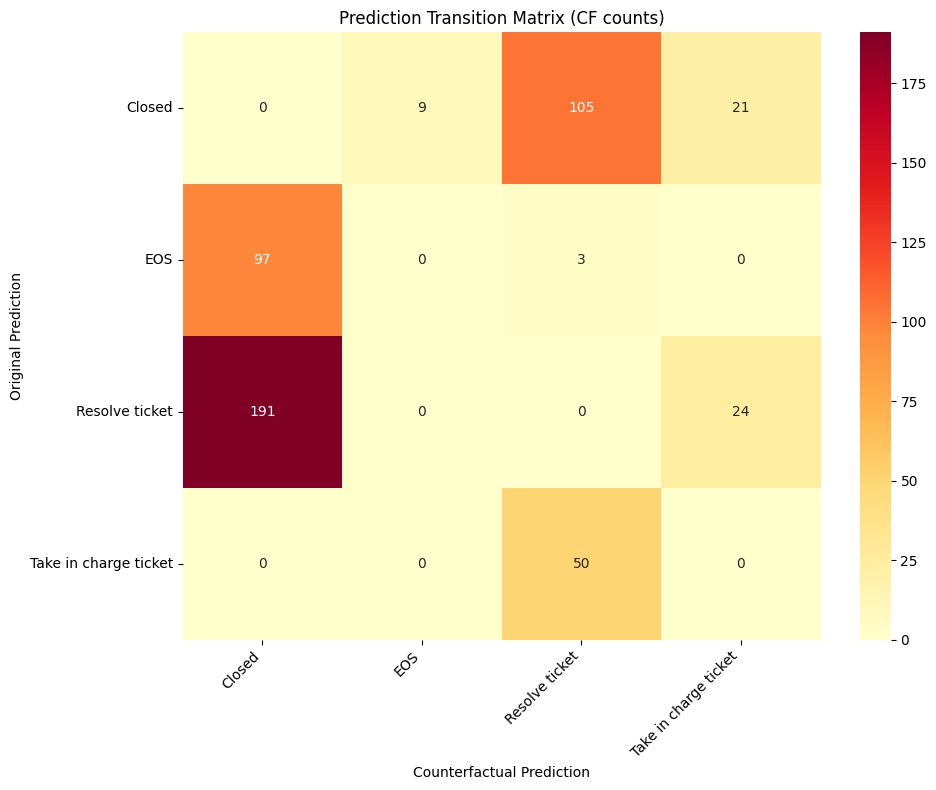


Top transitions by frequency:


,original_pred,cf_pred,count
5,Resolve ticket,Closed,191
1,Closed,Resolve ticket,105
3,EOS,Closed,97
7,Take in charge ticket,Resolve ticket,50
6,Resolve ticket,Take in charge ticket,24
2,Closed,Take in charge ticket,21
0,Closed,EOS,9
4,EOS,Resolve ticket,3


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Build transition count matrix
transition_counts = df_cfs.groupby(['original_pred', 'cf_pred']).size().reset_index(name='count')

# Get all unique classes that appear in transitions
all_classes = sorted(set(transition_counts['original_pred']) | set(transition_counts['cf_pred']))

# Pivot to matrix form
transition_matrix = transition_counts.pivot(index='original_pred', columns='cf_pred', values='count').fillna(0)
transition_matrix = transition_matrix.reindex(index=all_classes, columns=all_classes, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    transition_matrix.astype(int),
    annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=True, yticklabels=True,
    ax=ax,
)
ax.set_xlabel('Counterfactual Prediction')
ax.set_ylabel('Original Prediction')
ax.set_title('Prediction Transition Matrix (CF counts)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary table
print('\nTop transitions by frequency:')
display(transition_counts.sort_values('count', ascending=False).head(15))

## Analysis 2: Feature Importance

Which features are changed most often in successful counterfactuals?

Total individual feature changes: 1104


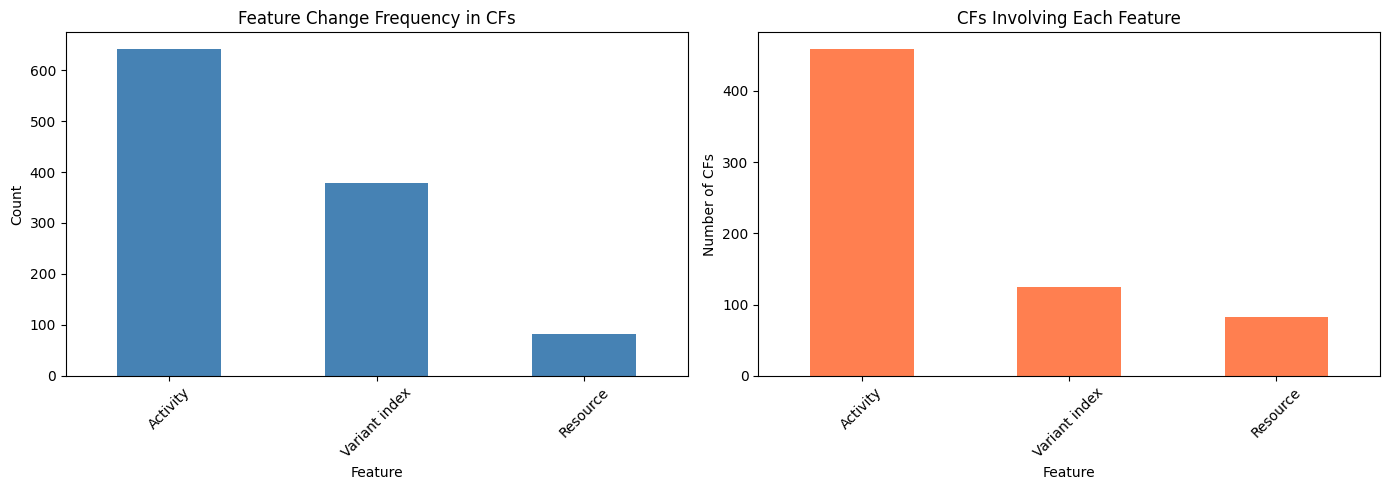

,total_changes,cfs_involved,pct_of_cfs
Activity,642,459,91.8
Variant index,379,125,25.0
Resource,83,82,16.4


In [9]:
# Flatten all changes
all_changes = []
for _, row in df_cfs.iterrows():
    for ch in row['changes']:
        all_changes.append(ch)

df_changes = pd.DataFrame(all_changes)
print(f'Total individual feature changes: {len(df_changes)}')

# (a) Frequency of each feature being changed
feature_freq = df_changes['feature'].value_counts()

# (b) Average number of positions changed per feature when it is involved
positions_per_feature = df_changes.groupby('feature')['position'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: feature change frequency
feature_freq.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Change Frequency in CFs')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Bar chart: CFs involving each feature (at least one change)
cf_involvement = {}
for _, row in df_cfs.iterrows():
    features_changed = set(ch['feature'] for ch in row['changes'])
    for feat in features_changed:
        cf_involvement[feat] = cf_involvement.get(feat, 0) + 1

involvement_series = pd.Series(cf_involvement).sort_values(ascending=False)
involvement_series.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('CFs Involving Each Feature')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Number of CFs')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary table
feat_summary = pd.DataFrame({
    'total_changes': feature_freq,
    'cfs_involved': involvement_series,
    'pct_of_cfs': (involvement_series / len(df_cfs) * 100).round(1),
})
display(feat_summary)

## Analysis 3: Positional Sensitivity

For each (feature, position), how often was that position changed? Shows whether early or late events matter more.

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.AutoLocator object at 0x31dbc8830>


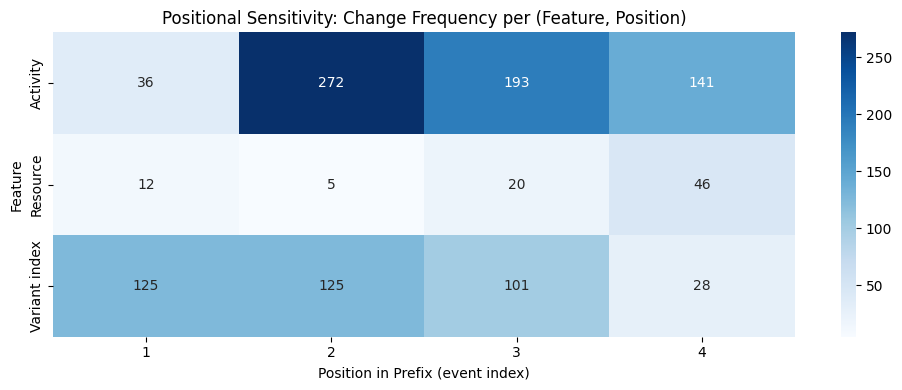

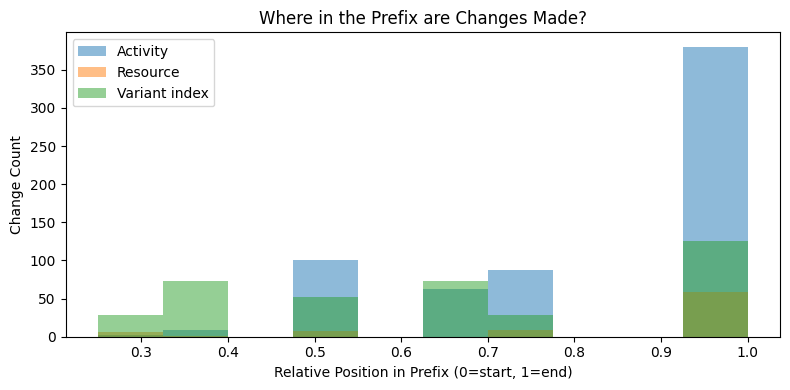

In [10]:
# Count changes per (feature, position)
pos_counts = df_changes.groupby(['feature', 'position']).size().reset_index(name='count')

# Get max position across all prefixes
max_pos = int(df_changes['position'].max())
features_sorted = sorted(df_changes['feature'].unique())

# Build matrix for heatmap
heat_data = pd.DataFrame(0, index=features_sorted, columns=range(1, max_pos + 1))
for _, row in pos_counts.iterrows():
    heat_data.loc[row['feature'], row['position']] = row['count']

fig, ax = plt.subplots(figsize=(max(10, max_pos * 0.8), max(4, len(features_sorted) * 1.2)))
sns.heatmap(
    heat_data, annot=True, fmt='d', cmap='Blues',
    xticklabels=True, yticklabels=True, ax=ax,
)
ax.set_xlabel('Position in Prefix (event index)')
ax.set_ylabel('Feature')
ax.set_title('Positional Sensitivity: Change Frequency per (Feature, Position)')
plt.tight_layout()
plt.show()

# Aggregate: early vs late positions
df_changes_with_rel = df_changes.copy()
# Join back prefix_len for each CF
# We need to map changes back to their prefix_len; use row index
change_records = []
for cf_idx, (_, row) in enumerate(df_cfs.iterrows()):
    plen = row['prefix_len']
    for ch in row['changes']:
        change_records.append({
            'feature': ch['feature'],
            'position': ch['position'],
            'relative_position': ch['position'] / plen,  # 0=start, 1=end
        })

df_rel = pd.DataFrame(change_records)
if len(df_rel) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    for feat in features_sorted:
        subset = df_rel[df_rel['feature'] == feat]
        if len(subset) > 0:
            ax.hist(subset['relative_position'], bins=10, alpha=0.5, label=feat)
    ax.set_xlabel('Relative Position in Prefix (0=start, 1=end)')
    ax.set_ylabel('Change Count')
    ax.set_title('Where in the Prefix are Changes Made?')
    ax.legend()
    plt.tight_layout()
    plt.show()

## Analysis 4: Minimal Changes

Distribution of sparsity (number of feature changes needed to flip the prediction).

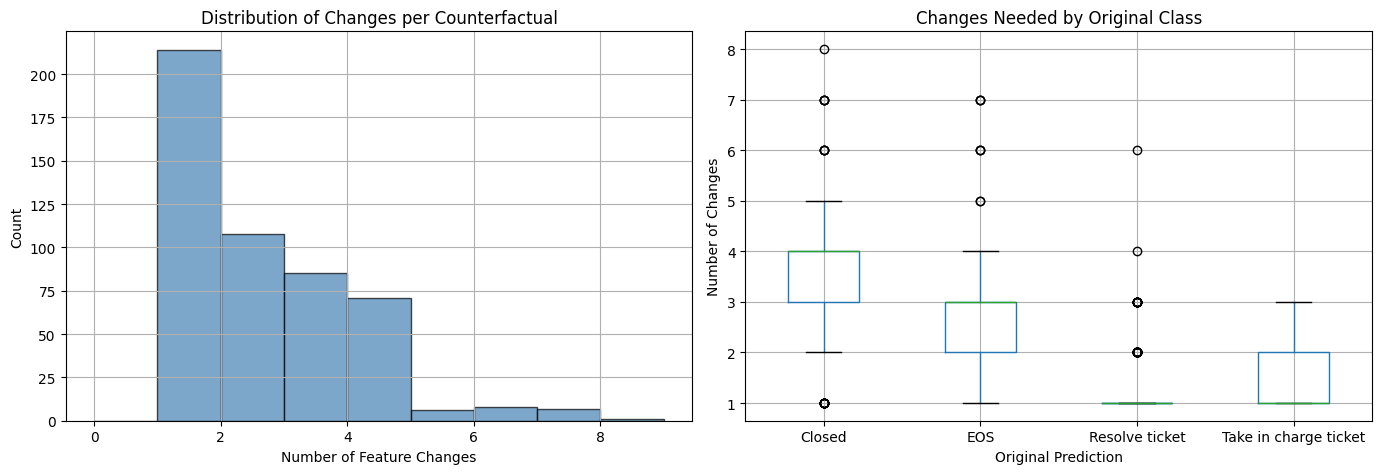


Sparsity statistics:


,count,mean,std,min,25%,50%,75%,max
original_pred,,,,,,,,
Closed,135.0,3.41,1.36,1.0,3.0,4.0,4.0,8.0
EOS,100.0,2.84,1.23,1.0,2.0,3.0,3.0,7.0
Resolve ticket,215.0,1.30,0.67,1.0,1.0,1.0,1.0,6.0
Take in charge ticket,50.0,1.60,0.81,1.0,1.0,1.0,2.0,3.0



Minimal-change CFs (best per prefix): median=1, mean=1.6


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of n_changes
df_cfs['n_changes'].hist(bins=range(0, df_cfs['n_changes'].max() + 2), ax=axes[0],
                          color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Feature Changes')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Changes per Counterfactual')

# Boxplot by original prediction class
orig_classes = df_cfs['original_pred'].unique()
if len(orig_classes) > 1:
    df_cfs.boxplot(column='n_changes', by='original_pred', ax=axes[1])
    axes[1].set_xlabel('Original Prediction')
    axes[1].set_ylabel('Number of Changes')
    axes[1].set_title('Changes Needed by Original Class')
    plt.suptitle('')  # remove auto-suptitle from boxplot
else:
    df_cfs['n_changes'].hist(bins=range(0, df_cfs['n_changes'].max() + 2), ax=axes[1],
                              color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_title(f'Changes (all original={orig_classes[0]})')

plt.tight_layout()
plt.show()

# Summary statistics
print('\nSparsity statistics:')
display(df_cfs.groupby('original_pred')['n_changes'].describe().round(2))

# Best (minimum changes) counterfactual per prefix
best_per_prefix = df_cfs.loc[df_cfs.groupby(['case_id', 'prefix_len'])['n_changes'].idxmin()]
print(f'\nMinimal-change CFs (best per prefix): median={best_per_prefix["n_changes"].median():.0f}, '
      f'mean={best_per_prefix["n_changes"].mean():.1f}')